# HW 2 - Descriptive Notebook

In this homework notebook, we will create a Wasserstein GAN with Convolution and Transpose Convolution layers for the MNIST Digit Generation dataset.

Get familiar with the code and write a small report (2 pages max), with answers to the questions listed at the end of the notebook.

**The report must be submitted in PDF format, before April 15th, 11.59pm!**

Do not forget to write your name and student ID on the report.

You may also submit your own copy of the notebook along with the report. If you do so, please add your name and ID to the cell below.

In [1]:
# Name: Sagar Pratap Singh
# Student ID: 1010736

In [2]:
# Dependencies for SUTD Cluster env
!pip install matplotlib

### Imports needed

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch import Tensor
from torch.autograd import Variable
import torch.autograd as autograd
from torchvision.utils import save_image

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print(device)

cuda


### Dataset and dataloader

In [5]:
# Image transform to be applied to dataset
# - Tensor conversion
# transform = transforms.Compose([transforms.ToTensor()])
transform = transforms.Compose([                                                                                               
  transforms.ToTensor(),      
  transforms.Normalize([0.5], [0.5])                                                                                         
])   

In [6]:
# MNIST train dataset
mnist = torchvision.datasets.MNIST(root = './data/',
                                   train = True,
                                   transform = transform,
                                   download = True)

In [7]:
# Data loader
batch_size = 64
data_loader = torch.utils.data.DataLoader(dataset = mnist,
                                          batch_size = batch_size,
                                          shuffle = True)

### Critic model as a set of Conv2d layers

**Task1:** Rewrite the Critic model below, so that it uses Conv2d layers instead of fully connected ones shown in class.

You may look for inspiration in the encoder models used in Notebook 3 (W9S1 lecture).

The critic should use three Conv2d layers with progressive downsampling.

We do not advise to add more layers to the mix (BatchNorm, Dropout, etc.).

In [8]:
# Critic
class Critic(nn.Module):

    def __init__(self, image_size):
        """
        Only forced parameter will be the image size, set to 28.
        """
        super().__init__()
        assert image_size == 28, "This architecture is written for 28x28 MNIST."

        # widened the convolutional encoder from 1->16->32->1 to 1->64->128->1 to learn stronger features and provide a sharper training signal to the generator
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),   # 28 -> 14
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=0)    # 7 -> 1
        )
    
    def forward(self, x):
        x = self.net(x)                  # (B, 1, 1, 1)
        return x.view(x.size(0), 1)      # (B, 1)


### Generator model as a set of Transposed Conv2d layers

**Task2:** Rewrite the Generator model below, so that it uses Transposed Conv2d layers instead of fully connected ones shown in class.

You may look for inspiration in the encoder models used in Notebooks 2 and 3 (W9S1 lecture).

The critic should use three Transposed Conv2d layers with progressive upsampling.

We do not advise to add more layers to the mix (BatchNorm, Dropout, etc.).

In [9]:
# Generator
class Generator(nn.Module):

    def __init__(self, latent_size, image_size):
        """
        Only forced parameters will be the image size, set to 28,
        and the latent size set to 64.
        """
        super().__init__()
        assert image_size == 28, "This architecture is written for 28x28 MNIST."

        # widened the transpose-convolution decoder from 64->32->16->1 style capacity to 64->128->64->1 to improve image synthesis quality and diversity 
        self.net = nn.Sequential(
          nn.ConvTranspose2d(latent_size, 128, kernel_size=7, stride=1, padding=0),   # 1 -> 7
          nn.ReLU(inplace=True),
    
          nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),             # 7 -> 14
          nn.ReLU(inplace=True),
    
          nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),              # 14 -> 28
          nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), x.size(1), 1, 1)   # (B, 64) -> (B, 64, 1, 1)
        return self.net(x)

### Trainer function

**Task 3:** Decide on a number of iterations num_epochs for training!

In [10]:
# Hyperparameters for model generation and training
latent_size = 64
image_size = 28
num_epochs = 100
lambda_gp = 10
n_critic = 5

In [11]:
# Create discriminator model
f = Critic(image_size)
f.to(device)

Critic(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(128, 1, kernel_size=(7, 7), stride=(1, 1))
  )
)

In [12]:
# Create generator model
G = Generator(latent_size, image_size)
G.to(device)

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(64, 128, kernel_size=(7, 7), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Tanh()
  )
)

In [13]:
# Losses and optimizers
d_optimizer = torch.optim.Adam(f.parameters(), lr=0.0001, betas=(0.5,0.9))
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0001, betas=(0.5,0.9))

In [14]:
# History trackers for training curves
# Keeping track of losses
d_losses = np.zeros(num_epochs)
g_losses = np.zeros(num_epochs)

**Note: running the cell below (our trainer function) will take a long time!**

In [15]:
total_step = len(data_loader)
for epoch in range(num_epochs):
  for i, (images, _) in enumerate(data_loader):

      images = images.to(device)

      # TRAIN CRITIC (n_critic steps per G step)
      for _ in range(n_critic):
          outputs_real = f(images)

          z = torch.randn(images.size(0), latent_size).to(device)
          fake_images = G(z).detach()
          outputs_fake = f(fake_images)

          # Gradient penalty on interpolated samples
          alpha = torch.rand(images.size(0), 1, 1, 1).to(device)
          interpolated = (alpha * images + (1 - alpha) * fake_images).requires_grad_(True)
          d_interpolated = f(interpolated)

          gradients = autograd.grad(
              outputs=d_interpolated,
              inputs=interpolated,
              grad_outputs=torch.ones_like(d_interpolated),
              create_graph=True,
              retain_graph=True)[0]
          gradients = gradients.view(gradients.size(0), -1)
          gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

          d_loss = -outputs_real.mean() + outputs_fake.mean() + lambda_gp * gradient_penalty

          d_optimizer.zero_grad()
          d_loss.backward()
          d_optimizer.step()

      # NO weight clipping

      # TRAIN GENERATOR
      z = torch.randn(images.size(0), latent_size).to(device)
      fake_images = G(z)
      outputs = f(fake_images)

      g_loss = -outputs.mean()

      g_optimizer.zero_grad()
      g_loss.backward()
      g_optimizer.step()

      # LOGGING
      d_losses[epoch] = d_losses[epoch] * (i/(i+1.)) + d_loss.item() * (1./(i+1.))
      g_losses[epoch] = g_losses[epoch] * (i/(i+1.)) + g_loss.item() * (1./(i+1.))

      if (i+1) % 200 == 0:
          print('Epoch [{}/{}], Step [{}/{}], d_loss: {:.4f}, g_loss:{:.4f}'
                .format(epoch, num_epochs, i+1, total_step,d_loss.item(), g_loss.item()))

Epoch [0/100], Step [200/938], d_loss: -20.2976, g_loss:-4.9593
Epoch [0/100], Step [400/938], d_loss: -10.0965, g_loss:-0.4425
Epoch [0/100], Step [600/938], d_loss: -5.5248, g_loss:3.9386
Epoch [0/100], Step [800/938], d_loss: -4.2797, g_loss:-1.9134
Epoch [1/100], Step [200/938], d_loss: -3.5706, g_loss:-4.2524
Epoch [1/100], Step [400/938], d_loss: -3.6223, g_loss:-4.7348
Epoch [1/100], Step [600/938], d_loss: -3.0707, g_loss:-3.1284
Epoch [1/100], Step [800/938], d_loss: -2.9928, g_loss:-3.8582
Epoch [2/100], Step [200/938], d_loss: -2.6778, g_loss:-2.5272
Epoch [2/100], Step [400/938], d_loss: -2.3014, g_loss:-2.7948
Epoch [2/100], Step [600/938], d_loss: -2.1862, g_loss:-1.9025
Epoch [2/100], Step [800/938], d_loss: -2.2350, g_loss:-4.0487
Epoch [3/100], Step [200/938], d_loss: -2.2911, g_loss:-4.3947
Epoch [3/100], Step [400/938], d_loss: -2.3584, g_loss:-4.1640
Epoch [3/100], Step [600/938], d_loss: -2.2094, g_loss:-2.6402
Epoch [3/100], Step [800/938], d_loss: -1.9552, g_loss

### Visualization

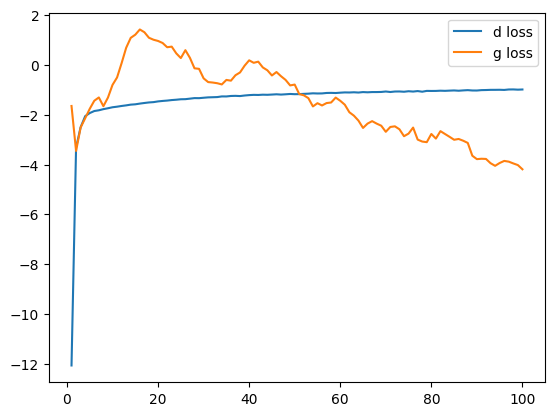

In [16]:
# Display losses for both the generator and discriminator
plt.figure()
plt.plot(range(1, num_epochs + 1), d_losses, label = 'd loss')
plt.plot(range(1, num_epochs + 1), g_losses, label = 'g loss')
plt.legend()
plt.show()

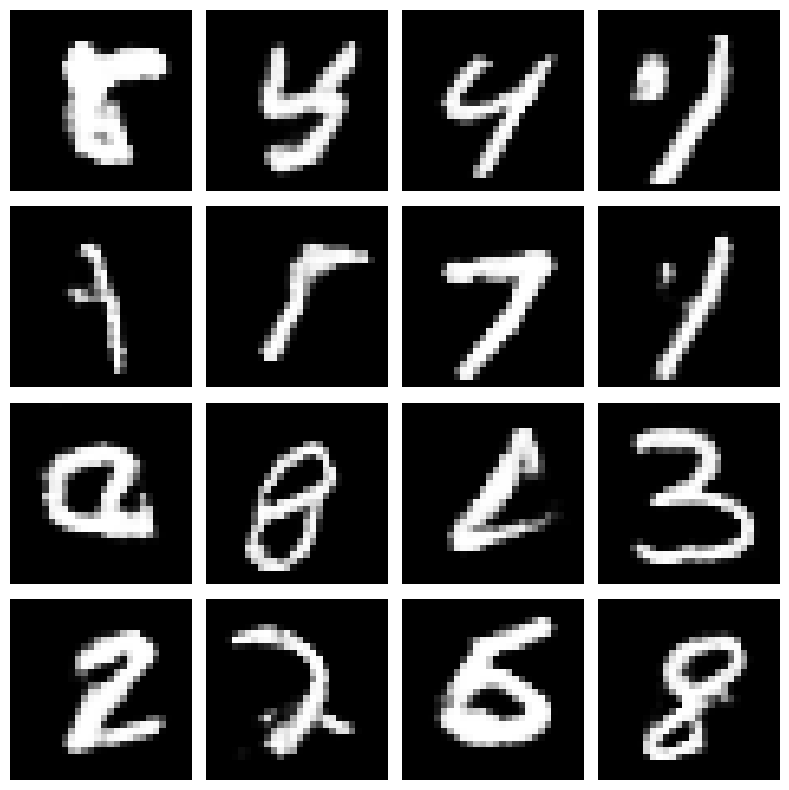

In [17]:
n_samples = 16
z = torch.randn(n_samples, latent_size).to(device)                                                                             
fake_images = G(z)                                                                                 
fake_images = fake_images.cpu().detach().numpy().reshape(n_samples, 28, 28)
fake_images = (fake_images + 1) / 2                                                                                            
                                          
fig, axes = plt.subplots(4, 4, figsize=(8, 8))                                                                                 
for idx, ax in enumerate(axes.flat):                                                               
  ax.imshow(fake_images[idx], cmap='gray')                                                                                   
  ax.axis('off')                          
plt.tight_layout()                                                                                                             
plt.show() 

### Questions and expected answers for the report

1. [15 points] Copy and paste the code for your Critic class. Briefly explain your choice of architecture.


2. [15 points] Copy and paste the code for your Generator class. Briefly explain your choice of architecture.


3. [5 points] For how many iterations did you have to train when using Wasserstein with Conv/TransposeConv layers to get plausible images from the generator? Is it training faster than the Fully Connected Wasserstein/Vanilla GAN?


4. [5 points] Display some samples generated by your trained generator. Do they look plausible?


5. [10 points] Let us assume we use Conv2d layers in the Critic. We do NOT use Transposed Conv2d layers, but only Fully Connected layers in the Generator. Would the GAN still be able to train both models or would it encounter difficulties? Discuss.